# Prediction de la reponse d'un traitement

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

### Chargement des données 

In [3]:
data = pd.read_csv("patient_treatment_data.csv")
data.head()

,Patient_ID,Age,Sexe,Antécédents_médicaux,Allergies,Maladie_traitée,Traitement_proposé,Compatibilité,Poids,Taille,IMC,Fumeur,Alcool,Activité_physique,Groupage_sanguin
0,1,60,M,Aucun,Aspirine,Migraines,Traitement D,Non,55.3,150.6,22.9,Oui,Oui,Moyenne,AB-
1,2,64,M,Asthme,Sulfamides,Diabète,Traitement B,Oui,76.4,157.0,28.1,Oui,Non,Élevée,O-
2,3,64,M,Diabète,Sulfamides,Anémie,Traitement D,Non,73.6,187.3,18.7,Oui,Non,Faible,B+
3,4,42,F,Cardiopathie,Sulfamides,Anémie,Traitement B,Non,97.0,194.3,32.8,Oui,Oui,Élevée,O-
4,5,67,M,Aucun,Pénicilline,Migraines,Traitement A,Oui,83.6,196.2,29.3,Oui,Oui,Faible,O+


### Prétraitement des données

##### Vérification des valeurs manquantes 

In [8]:
print(data.isnull().sum())
data1 = data

Patient_ID              0
Age                     0
Sexe                    0
Antécédents_médicaux    0
Allergies               0
Maladie_traitée         0
Traitement_proposé      0
Compatibilité           0
Poids                   0
Taille                  0
IMC                     0
Fumeur                  0
Alcool                  0
Activité_physique       0
Groupage_sanguin        0
dtype: int64


Le résultat indique qu'il n'y a aucune valeur manquante dans notre dataset pour toutes les colonnes.

####  Encodage des variables catégoriques

In [9]:
# Encodage LabelEncoder
le = LabelEncoder()
data["Sexe"] = le.fit_transform(data["Sexe"])  # M = 1, F = 0

In [10]:
data["Antécédents_médicaux"] = le.fit_transform(data["Antécédents_médicaux"])
data["Allergies"] = le.fit_transform(data["Allergies"])
data["Maladie_traitée"] = le.fit_transform(data["Maladie_traitée"])
data["Traitement_proposé"] = le.fit_transform(data["Traitement_proposé"])
data["Fumeur"] = le.fit_transform(data["Fumeur"])
data["Alcool"] = le.fit_transform(data["Alcool"])
data["Activité_physique"] = le.fit_transform(data["Activité_physique"])

In [11]:
# Encodage One-Hot Encoding
data = pd.get_dummies(data, columns=["Groupage_sanguin"], drop_first=True)
data.head()

,Patient_ID,Age,Sexe,Antécédents_médicaux,Allergies,Maladie_traitée,Traitement_proposé,Compatibilité,Poids,Taille,...,Fumeur,Alcool,Activité_physique,Groupage_sanguin_A-,Groupage_sanguin_AB+,Groupage_sanguin_AB-,Groupage_sanguin_B+,Groupage_sanguin_B-,Groupage_sanguin_O+,Groupage_sanguin_O-
0,1,60,1,1,0,3,3,Non,55.3,150.6,...,1,1,1,False,False,True,False,False,False,False
1,2,64,1,0,4,1,1,Oui,76.4,157.0,...,1,0,2,False,False,False,False,False,False,True
2,3,64,1,3,4,0,3,Non,73.6,187.3,...,1,0,0,False,False,False,True,False,False,False
3,4,42,0,2,4,0,1,Non,97.0,194.3,...,1,1,2,False,False,False,False,False,False,True
4,5,67,1,1,3,3,0,Oui,83.6,196.2,...,1,1,0,False,False,False,False,False,True,False


#### Gestion des outliers

Détectez et traitez les valeurs aberrantes (outliers) pour éviter d’influencer négativement le modèle.

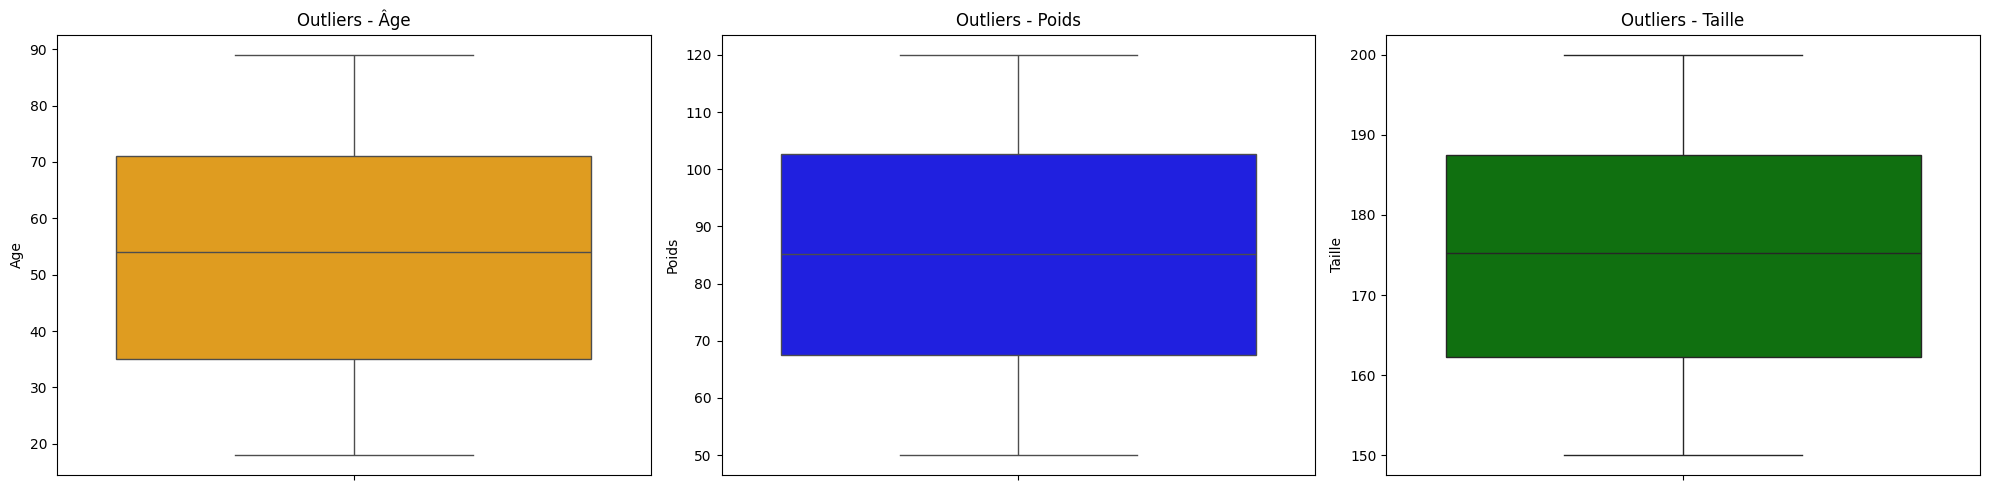

In [12]:
# Boîtes à moustaches (Boxplots) pour détecter les outliers :
fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # 1 ligne, 3 colonnes

# Boxplot pour chaque colonne
sns.boxplot(data1["Age"], ax=axes[0], color="orange")  # Âge
axes[0].set_title("Outliers - Âge")

sns.boxplot(data1["Poids"], ax=axes[1], color="blue")  # Poids
axes[1].set_title("Outliers - Poids")

sns.boxplot(data1["Taille"], ax=axes[2], color="green")  # Taille
axes[2].set_title("Outliers - Taille")

# Ajuster l'espacement
plt.tight_layout()
plt.show()

**Boîte principale** :
Représente l'intervalle interquartile (IQR), c'est-à-dire les 50 % des valeurs médianes.
La ligne horizontale au milieu représente la médiane.

**Lignes ("moustaches")** :
Montrent la plage des données sans valeurs aberrantes, généralement jusqu'à 1,5 fois l'IQR.


**Pas de points isolés** :
Aucune valeur aberrante détectée dans cet intervalle.

#### Transformation des variables numériques

In [13]:
# Normalisation Min-Max
scaler = MinMaxScaler()
data[["Age", "Poids", "Taille", "IMC"]] = scaler.fit_transform(
    data[["Age", "Poids", "Taille", "IMC"]]
)
data.head()

,Patient_ID,Age,Sexe,Antécédents_médicaux,Allergies,Maladie_traitée,Traitement_proposé,Compatibilité,Poids,Taille,...,Fumeur,Alcool,Activité_physique,Groupage_sanguin_A-,Groupage_sanguin_AB+,Groupage_sanguin_AB-,Groupage_sanguin_B+,Groupage_sanguin_B-,Groupage_sanguin_O+,Groupage_sanguin_O-
0,1,0.591549,1,1,0,3,3,Non,0.075714,0.012,...,1,1,1,False,False,True,False,False,False,False
1,2,0.647887,1,0,4,1,1,Oui,0.377143,0.140,...,1,0,2,False,False,False,False,False,False,True
2,3,0.647887,1,3,4,0,3,Non,0.337143,0.746,...,1,0,0,False,False,False,True,False,False,False
3,4,0.338028,0,2,4,0,1,Non,0.671429,0.886,...,1,1,2,False,False,False,False,False,False,True
4,5,0.690141,1,1,3,3,0,Oui,0.480000,0.924,...,1,1,0,False,False,False,False,False,True,False


#### Création de nouvelles variables (Feature Engineering)

Ajoutez des variables pertinentes pour enrichir les données.

In [14]:
# Catégorisation de l’IMC : Basé sur les seuils définis par l’OMS :
def categoriser_imc(imc):
    if imc < 18.5:
        return "Sous-poids"
    elif 18.5 <= imc < 25:
        return "Normal"
    elif 25 <= imc < 30:
        return "Surpoids"
    else:
        return "Obèse"


data["IMC_catégorie"] = data["IMC"].apply(categoriser_imc)
data["IMC_catégorie"] = le.fit_transform(data["IMC_catégorie"])

**Nombre d’antécédents médicaux** : Si les antécédents sont une chaîne de caractères délimitée par des virgules :

#### Division des données

Divisez les données en ensemble d’entraînement et ensemble de test

In [15]:
# Séparation des features et de la cible :
X = data.drop(columns=["Compatibilité"])  # Supprimez la cible
y = data["Compatibilité"].map({"Oui": 1, "Non": 0})  # Convertir en 0 et 1

In [16]:
# Division en ensembles d’entraînement/test :
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Model de machine learning

In [53]:
import joblib  # Pour sauvegarder le modèle
import seaborn as sns
from sklearn.linear_model import (
    LogisticRegression,  # Remplacer par LogisticRegression pour classification
)
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Création du modèle de régression logistique (adapté à la classification binaire)
model = LogisticRegression()

# Entraînement du modèle
model.fit(X_train, y_train)

# Sauvegarder le modèle avec joblib
joblib.dump(model, "logistic_model.pkl")

# Faire des prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
print("Précision (Accuracy) :", accuracy)

# Rapport de classification (Précision, Rappel, F1-score)
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Précision (Accuracy) : 0.5115
Rapport de classification :
              precision    recall  f1-score   support

           0       0.50      0.58      0.54       980
           1       0.52      0.45      0.48      1020

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000

